In [25]:
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..'))  # go up one level to project root

from data_prep import get_cat_map, load_and_clean

df = load_and_clean()

In [26]:

# Add a new column 'category' to the DataFrame by mapping numeric category_id to the category name
cat_map = get_cat_map()
df['category'] = df['category_id'].map(cat_map)

In [27]:
# Defining a weighted virality score to determine trending capacity
df['virality_score'] = 0.5*df['likes'] + 0.3*df['comment_count'] + 0.2*df['views']

In [28]:
# Outputting the virality_score from least to greatest
df.groupby('category')['virality_score'].mean().sort_values(ascending=True)

# Output shows us that News & Politics, Education, and Travel & Events are 
# amongst the least viral subjects. Contrarily, categories like Film & Animation,
# Nonprofits & Activism, and Music are the most viral. 

category
News & Politics          1.228953e+05
Education                1.584466e+05
Travel & Events          1.776194e+05
Pets & Animals           1.776239e+05
Shows                    1.907029e+05
Howto & Style            2.180641e+05
Autos & Vehicles         2.773341e+05
Science & Technology     3.092106e+05
Comedy                   3.293093e+05
People & Blogs           3.377507e+05
Sports                   4.294202e+05
Entertainment            4.424133e+05
Gaming                   5.718300e+05
Film & Animation         6.589323e+05
Nonprofits & Activism    7.480481e+05
Music                    1.355468e+06
Name: virality_score, dtype: float64

In [ ]:
# Hourly engagement
df['engagement_rate'] = (df['likes'] + df['comment_count']) / df['views']
hour_engagement = df.groupby('publish_hour')['engagement_rate'].mean()
print(hour_engagement)

publish_hour
0     0.039720
1     0.038410
2     0.032052
3     0.032582
4     0.031456
5     0.041534
6     0.025943
7     0.028752
8     0.029275
9     0.036184
10    0.027563
11    0.032770
12    0.031681
13    0.033227
14    0.035823
15    0.039604
16    0.040981
17    0.040031
18    0.041499
19    0.048023
20    0.042792
21    0.044719
22    0.044605
23    0.045760
Name: engagement_rate, dtype: float64


In [ ]:
# Engagement by day of the week 
day_engagement = df.groupby('publish_day')['engagement_rate'].mean()
print(day_engagement)

publish_day
0    0.036850
1    0.039281
2    0.040158
3    0.039436
4    0.039336
5    0.038884
6    0.037125
Name: engagement_rate, dtype: float64


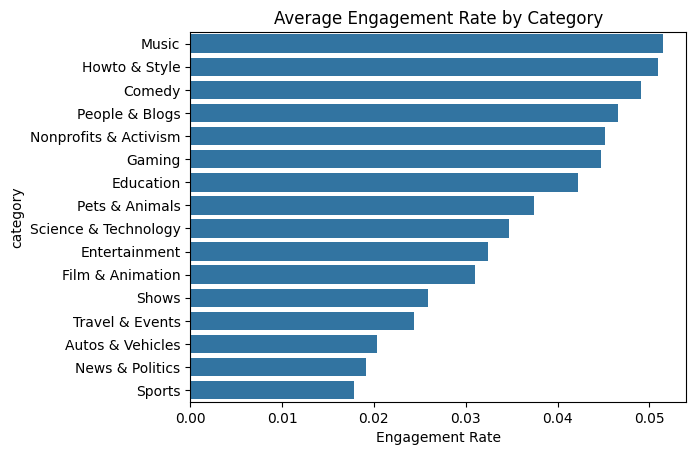

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

category_engagement = df.groupby('category')['engagement_rate'].mean().sort_values(ascending=False)
sns.barplot(x=category_engagement.values, y=category_engagement.index)
plt.title("Average Engagement Rate by Category")
plt.xlabel("Engagement Rate")
plt.show()